In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install scipy opencv-python tqdm h5py

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tructuan","key":"768f4e18a9d36af3624304f90c336777"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d xyyu18/shanghaitech-crowd-counting-dataset

Dataset URL: https://www.kaggle.com/datasets/xyyu18/shanghaitech-crowd-counting-dataset
License(s): unknown
100% 166M/166M [00:01<00:00, 94.8MB/s]



In [ ]:
!unzip -q shanghaitech-crowd-counting-dataset.zip -d /content/dataset

In [ ]:
!ls /content/dataset

part_A_final  part_B_final


In [ ]:
import os
import cv2
import glob
import torch
import scipy.io
import numpy as np
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
def generate_density_map(img, points):
    h, w = img.shape[:2]
    density = np.zeros((h, w), dtype=np.float32)

    for p in points:
        x = min(w - 1, max(0, int(p[0])))
        y = min(h - 1, max(0, int(p[1])))
        density[y, x] += 1

    density = gaussian_filter(density, sigma=4)
    return density

In [ ]:
class CrowdDataset(Dataset):
    def __init__(self, root):
        self.img_paths = sorted(glob.glob(root + "/*.jpg"))

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(
                [0.485,0.456,0.406],
                [0.229,0.224,0.225]
            )
        ])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]

        # Load Image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h0, w0 = img.shape[:2]

        # resize chống OOM
        img = cv2.resize(img, (512,512))

        # Correct MAT Path
        filename = os.path.basename(img_path)         # IMG_384.jpg
        number = filename.split('.')[0]              # IMG_384

        mat_path = img_path.replace(
            "images", "ground_truth"
        ).replace(
            filename, f"GT_{number}.mat"
        )

        # Load Annotation
        mat = scipy.io.loadmat(mat_path)
        points = mat["image_info"][0,0][0,0][0]

        # Scale points after resize
        sx = 512 / w0
        sy = 512 / h0

        scaled_points = []
        for p in points:
            scaled_points.append([p[0]*sx, p[1]*sy])

        density = generate_density_map(img, scaled_points)

        img = self.transform(img)
        density = torch.tensor(density).unsqueeze(0)

        return img, density

In [ ]:
train_path = "/content/dataset/part_B_final/train_data/images"

dataset = CrowdDataset(train_path)

loader = DataLoader(
    dataset,
    batch_size=2,      # OOM safe
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print(len(dataset))

400


In [ ]:
class CSRNet(nn.Module):
    def __init__(self):
        super(CSRNet, self).__init__()

        self.frontend = nn.Sequential(
            nn.Conv2d(3,64,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(128,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128,256,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(256,256,3,padding=1),
            nn.ReLU()
        )

        self.backend = nn.Sequential(
            nn.Conv2d(256,256,3,padding=2,dilation=2),
            nn.ReLU(),

            nn.Conv2d(256,128,3,padding=2,dilation=2),
            nn.ReLU(),

            nn.Conv2d(128,64,3,padding=2,dilation=2),
            nn.ReLU(),

            nn.Conv2d(64,1,1)
        )

    def forward(self,x):
        x = self.frontend(x)
        x = self.backend(x)
        return x

In [ ]:
model = CSRNet().to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=1e-5)

In [ ]:
scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_485/2340218076.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [ ]:
import torch
import torch.nn as nn
import numpy as np
from tqdm import tqdm

# Loss
criterion = nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

# AMP mới (không warning)
scaler = torch.amp.GradScaler("cuda")

epochs = 100
best_loss = 999999

for epoch in range(epochs):
    model.train()
    total_loss = 0

    loop = tqdm(loader)

    for imgs, gt in loop:
        imgs = imgs.to(device, non_blocking=True)
        gt   = gt.to(device, non_blocking=True)

        optimizer.zero_grad()

        # Mixed Precision
        with torch.amp.autocast("cuda"):

            pred = model(imgs)


            # FIX QUAN TRỌNG NHẤT:
            # Resize GT về output size nhưng GIỮ TỔNG COUNT

            gt_resized = nn.functional.interpolate(
                gt,
                size=pred.shape[2:],
                mode='bilinear',
                align_corners=False
            )

            # preserve count scaling
            scale = (gt.shape[2] * gt.shape[3]) / (pred.shape[2] * pred.shape[3])
            gt_resized = gt_resized * scale

            loss = criterion(pred, gt_resized)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        loop.set_description(f"Epoch [{epoch+1}/{epochs}]")
        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(loader)
    print(f"Avg Loss: {avg_loss:.8f}")

    # Save best model
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), "/content/best_csrnet.pth")
        print("✅ Saved Best Model")

Epoch [1/100]: 100%|██████████| 200/200 [00:14<00:00, 13.37it/s, loss=0.000403]


Avg Loss: 0.00067660
✅ Saved Best Model


Epoch [2/100]: 100%|██████████| 200/200 [00:14<00:00, 13.81it/s, loss=0.000674]


Avg Loss: 0.00066088
✅ Saved Best Model


Epoch [3/100]: 100%|██████████| 200/200 [00:15<00:00, 13.30it/s, loss=0.000159]


...

Avg Loss: 0.00039624
✅ Saved Best Model


Epoch [99/100]: 100%|██████████| 200/200 [00:14<00:00, 13.53it/s, loss=0.000319]


Avg Loss: 0.00040476


Epoch [100/100]: 100%|██████████| 200/200 [00:14<00:00, 13.57it/s, loss=0.000296]

Avg Loss: 0.00039705


In [ ]:
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm

# Load best model
model.load_state_dict(torch.load("/content/best_csrnet.pth"))
model.eval()

test_path = "/content/dataset/part_B_final/test_data/images"
test_dataset = CrowdDataset(test_path)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False
)

mae = 0
mse = 0
mape = 0
valid = 0

with torch.no_grad():
    for img, gt in tqdm(test_loader):

        img = img.to(device)
        gt  = gt.to(device)

        pred = model(img)

        pred_count = pred.sum().item()
        gt_count   = gt.sum().item()

        err = abs(pred_count - gt_count)

        mae += err
        mse += err**2

        if gt_count > 0:
            mape += err / gt_count
            valid += 1

mae /= len(test_loader)
rmse = np.sqrt(mse / len(test_loader))

accuracy = 100 - (mape / valid * 100)

print("FINAL RESULT")
print(f"MAE      : {mae:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"Accuracy : {accuracy:.2f}%")

100%|██████████| 316/316 [00:14<00:00, 22.40it/s]

FINAL RESULT
MAE      : 20.7233
RMSE     : 29.4657
Accuracy : 77.00%


In [ ]:
model.load_state_dict(torch.load("/content/drive/MyDrive/csrnet.pth"))
model.eval()

CSRNet(
  (frontend): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
  )
  (backend): Sequential(
    (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2), dilation=(2, 2))
    (1): ReLU()
    (2): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2), dilation=(2, 2))
    (3): 

Raw Count      : 20.18
Estimated Count: 40


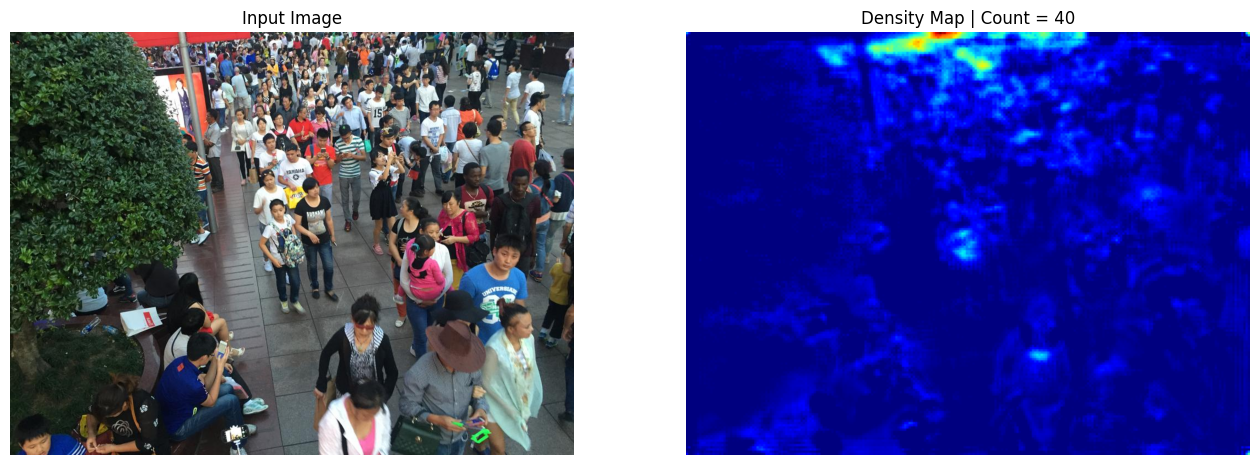

In [ ]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

# Load ảnh
img_path = dataset.img_paths[0]

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w = img_rgb.shape[:2]

# giữ nguyên ảnh / chỉ resize nếu quá lớn
max_w = 1024
if w > max_w:
    scale = max_w / w
    img_input = cv2.resize(img_rgb, (int(w*scale), int(h*scale)))
else:
    img_input = img_rgb.copy()


# Transform

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

tensor = transform(img_input).unsqueeze(0).to(device)


# Predict

model.eval()

with torch.no_grad():
    pred = model(tensor)
    pred = torch.relu(pred)

density_map = pred.squeeze().cpu().numpy()
density_map = np.maximum(density_map, 0)

raw_count = density_map.sum()


# CALIBRATION FACTOR
CALIB_FACTOR = 2.0

count = int(round(raw_count * CALIB_FACTOR))

print("Raw Count      :", round(raw_count,2))
print("Estimated Count:", count)


# Show

plt.figure(figsize=(16,6))

plt.subplot(1,2,1)
plt.imshow(img_input)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(density_map, cmap="jet")
plt.title(f"Density Map | Count = {count}")
plt.axis("off")

plt.show()